In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np

module_path = os.path.abspath(os.path.join('../HouseBlend'))
if module_path not in sys.path:
    sys.path.append(module_path)
import HouseBlend as hb

In [2]:
parent_dir = 'example'

### advanced - change if required
parent_fullpath = os.path.join('../', parent_dir)

In [3]:
### Test time taken to solve
participant_num = list(range(4, 8, 2))
times = np.zeros(len(participant_num))

n_periods=None
current_period=1

for n, num in enumerate(participant_num):
  print(num)
  contacts, dates, availability = hb.import_contacts_df(folderpath=parent_fullpath, test=num)

  # import current schedule dataframe
  schedule, bool_schedule = hb.import_schedules(folderpath=parent_fullpath, test=True)
  start_time = time.time()
  bool_schedule = hb.run_schedule_optimisation(contacts, bool_schedule, n_periods, availability)
  end_time = time.time()
  times[n] = end_time - start_time

4
Deleting previous contacts file
Creating new contact directory of 4 length for testing
Deleting previous schedule files
No existing schedule found. Ensure current_period is set to 1.
6
Deleting previous contacts file
Creating new contact directory of 6 length for testing
Deleting previous schedule files
No existing schedule found. Ensure current_period is set to 1.


In [7]:
%%capture

### Test time taken to solve
participant_num = list(range(4, 15, 2))

n_periods = participant_num[-1] - (participant_num[-1] % 2 == 0)
current_period=1
times = np.zeros((len(participant_num), n_periods))

for n, num in enumerate(participant_num):
    max_periods = num - (num % 2 == 0)
    periods = list(range(1, max_periods+1))
    for p, period in enumerate(periods):
        if period==1:
            continue
        print(f"Participants: {num}, Periods: {period}")
        contacts, dates, availability = hb.import_contacts_df(folderpath=parent_fullpath, test=num)
        schedule, bool_schedule = hb.import_schedules(folderpath=parent_fullpath, test=True)
        start_time = time.time()
        bool_schedule = hb.run_schedule_optimisation(contacts, bool_schedule, period, availability, current_period=current_period)
        end_time = time.time()
        times[n,p] = end_time - start_time

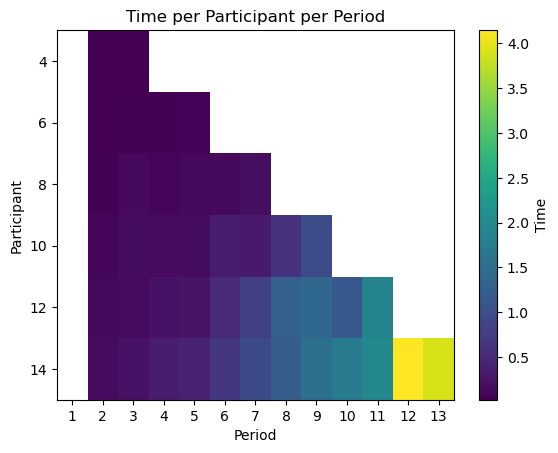

In [8]:
times[times==0]=np.nan
plt.imshow(times, aspect='auto', cmap='viridis')  # You can change cmap to any other color map

# Optional: add axis labels and a color bar
plt.xlabel('Period')
plt.ylabel('Participant')
plt.colorbar(label='Time')  # Assumes times is some time measure

# Set integer ticks
plt.xticks(ticks=np.arange(n_periods), labels=np.arange(1, n_periods+1))      # Integer period labels
plt.yticks(ticks=np.arange(len(participant_num)), labels=participant_num) # Integer participant labels

plt.title('Time per Participant per Period')
plt.show()

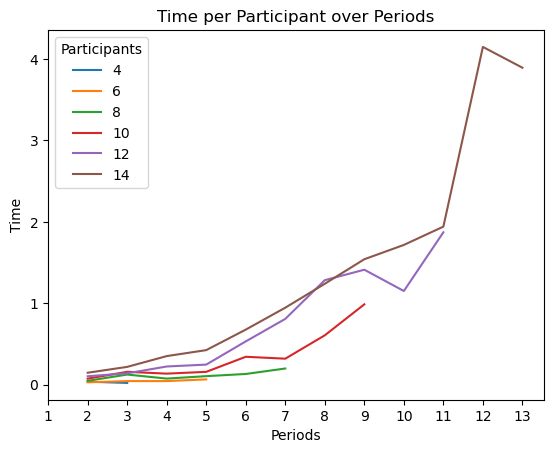

In [9]:

n_participants, n_periods = times.shape

# Transpose so each participant's time series is a line
for i, num in enumerate(participant_num):
    plt.plot(times[i], label=f'{num}')

plt.xticks(ticks=np.arange(n_periods), labels=list(range(1, n_periods+1)))
plt.xlabel('Periods')
plt.ylabel('Time')
plt.legend(title='Participants')  # Show the legend
plt.title('Time per Participant over Periods')
plt.show()

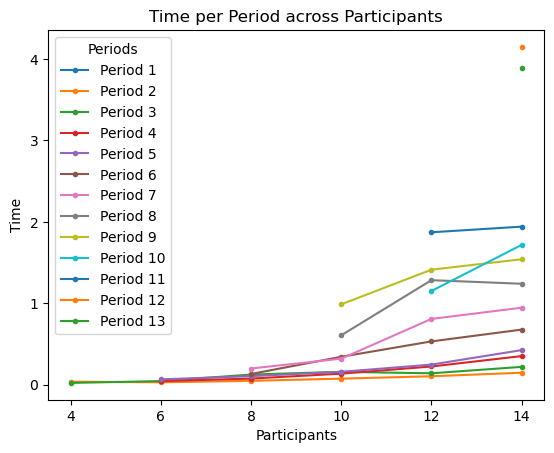

In [10]:
n_participants, n_periods = times.shape

# Plot each period's time across participants
for i in range(n_periods):
    plt.plot(times[:, i], label=f'Period {i+1}', marker='.')

plt.xticks(ticks=np.arange(n_participants), labels=participant_num)
plt.xlabel('Participants')
plt.ylabel('Time')
plt.legend(title='Periods')
plt.title('Time per Period across Participants')
plt.show()


In [11]:
max_periods_times = [np.nanmax(times[p,:]) for p in range(times.shape[0])]

([<matplotlib.axis.XTick at 0x144e88d40>,
 [Text(0, 0, '4'),
  Text(1, 0, '6'),
  Text(2, 0, '8'),
  Text(3, 0, '10'),
  Text(4, 0, '12'),
  Text(5, 0, '14')])

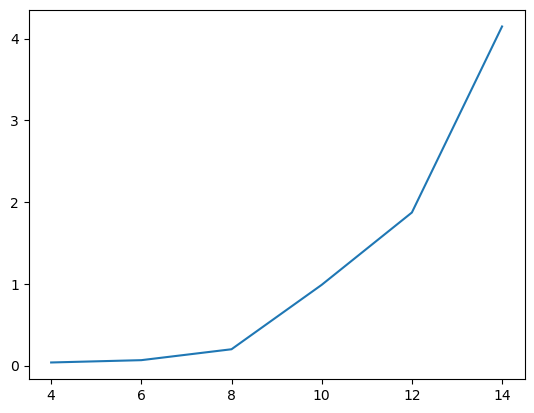

In [12]:
plt.plot(max_periods_times)
plt.xticks(ticks=np.arange(n_participants), labels=participant_num)

In [13]:
from scipy.optimize import curve_fit
def model(x, a, b):
    return a * np.exp(b * x)

# Fit the curve
params, covariance = curve_fit(model, participant_num, max_periods_times, p0=(1, 0.5))  # p0 is initial guess
params[0], params[1]

(np.float64(0.014963230615092856), np.float64(0.40203563408602994))

In [14]:
y_fit = model(np.array(participant_num), params[0], params[1])

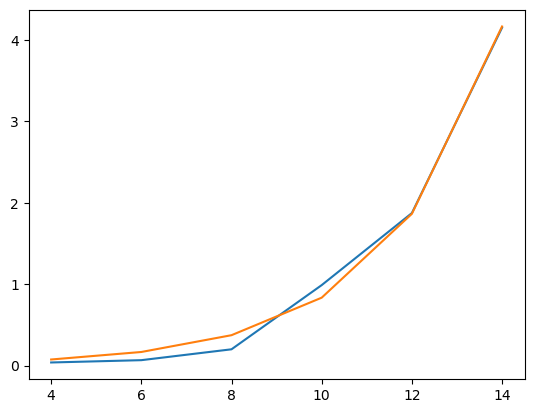

In [15]:
plt.plot(max_periods_times)
plt.xticks(ticks=np.arange(n_participants), labels=participant_num)
plt.plot(y_fit)

In [21]:
y_40 = model(40.0, params[0], params[1])
print("{:.1f} hours".format(y_40/(60*60)))

40.1 hours


In [127]:
p5s = times[:,4]

In [130]:
p5s

array([        nan,  0.59548616,  1.46558714,  3.29634881,  6.26225924,
       10.48321414])

In [133]:
# Fit the curve
params, covariance = curve_fit(model, participant_num[1:], p5s[1:], p0=(1, 0.5))  # p0 is initial guess
params[0], params[1]
fit_p5 = model(np.array(participant_num[1:]), params[0], params[1])

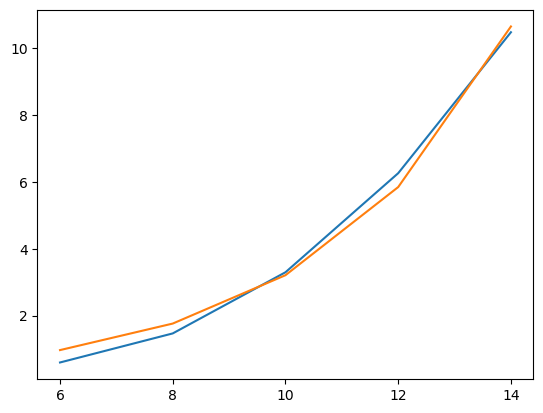

In [141]:
plt.plot(p5s)
plt.xticks(ticks=np.arange(n_participants), labels=participant_num)
plt.plot(np.arange(n_participants)[1:], fit_p5)

In [143]:
y_40 = model(30.0, params[0], params[1])
print("{:.1f} hours".format(y_40/(60*60)))

0.4 hours
